In [84]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import random as rd
import math

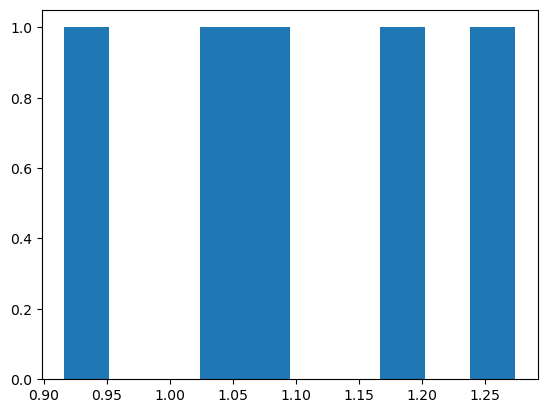

In [85]:
N_sample = 5
L_single = sp.stats.norm(loc=1, scale=0.2)
mock_sample = [rd.gauss(1, 0.2) for _ in range(N_sample)]
plt.hist(mock_sample)
plt.show()

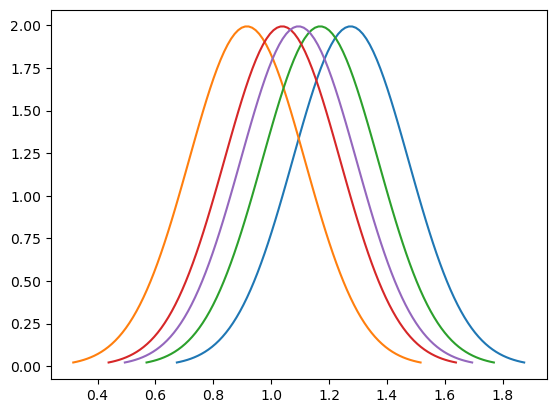

In [86]:
for elem in mock_sample[:10]: #plotting only the first 10 points not to mess the plot
    plt.plot(np.linspace(elem-0.6, elem+0.6, 100), np.ones(100)*sp.stats.norm(loc=elem, scale=0.2).pdf(np.linspace(elem-0.6, elem+0.6, 100)))

In [87]:
def L_tot(x): return math.prod(sp.stats.norm(loc=elem, scale=0.2).pdf(x) for elem in mock_sample)

mu grd 1.0985985985985987
mu MLE 1.0985123315301597


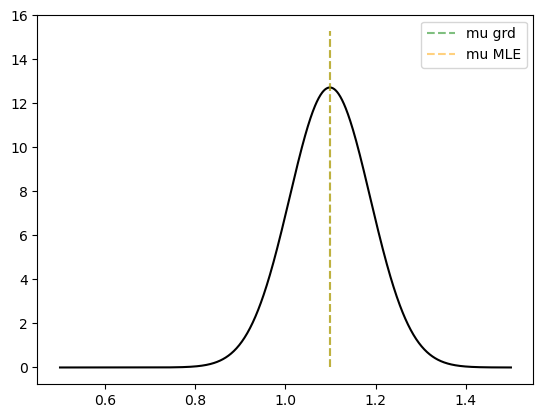

In [88]:
xx = np.linspace(0.5, 1.5, 1000)
mu_grd = xx[np.argmax(L_tot(xx))]
mu_MLE = np.mean(mock_sample)
print('mu grd', mu_grd)
print('mu MLE', mu_MLE)
plt.plot(xx, L_tot(xx), c='black')
plt.vlines(mu_grd, 0, np.max(L_tot(xx))*1.2, ls='dashed', color='green', label='mu grd', alpha=0.5)
plt.vlines(mu_MLE, 0, np.max(L_tot(xx))*1.2, ls='dashed', color='orange', label='mu MLE', alpha=0.5)
plt.legend()
plt.show()

# Part 2

In [94]:
FMEN = 1 / np.max(np.sqrt(np.diff(np.log(L_tot(xx)), n=2) / (xx[1]-xx[0])**2 * (-1))) #Fischer Matrix Error, Numerical
FMET = 0.2 / np.sqrt(N_sample)

In [96]:
print('FME theor', FMET)
print('FME numer', FMEN)

FME theor 0.08944271909999159
FME numer 0.08944271909369717


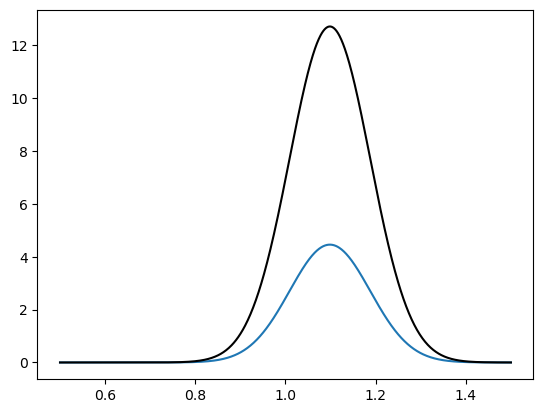

In [ ]:
plt.plot(xx, sp.stats.norm.pdf(xx, loc=mu_MLE, scale=FMEN), c='red', label='Fischer Matrix')
plt.plot(xx, L_tot(xx), c='blue')
plt.show()